***Baseline Model***

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/Projects/Project for Uni 2/data/EU-Park-Customers.csv")
df['Pass_Type'] = df['Pass_Type'].fillna('None')

df = df.drop(columns=['Telephone_Number'])

y = df['Pass_Type']

X = df.drop(columns=['Pass_Type'])

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

        Gold       0.87      0.86      0.86       559
        None       0.91      0.91      0.91       874
      Silver       0.72      0.74      0.73       567

    accuracy                           0.85      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.85      0.85      0.85      2000



In [3]:
df.describe()

,Age,Family_Members_with_Passes,Previously_Owned_Passes,Distance_from_Park_km
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,43.539400,0.752500,2.017000,29.936617
std,14.911636,0.891809,1.414606,29.455316
min,18.000000,0.000000,0.000000,0.000826
25%,31.000000,0.000000,1.000000,8.600811
50%,43.000000,1.000000,2.000000,20.788702
75%,56.000000,1.000000,3.000000,41.993392
max,69.000000,3.000000,4.000000,246.639786


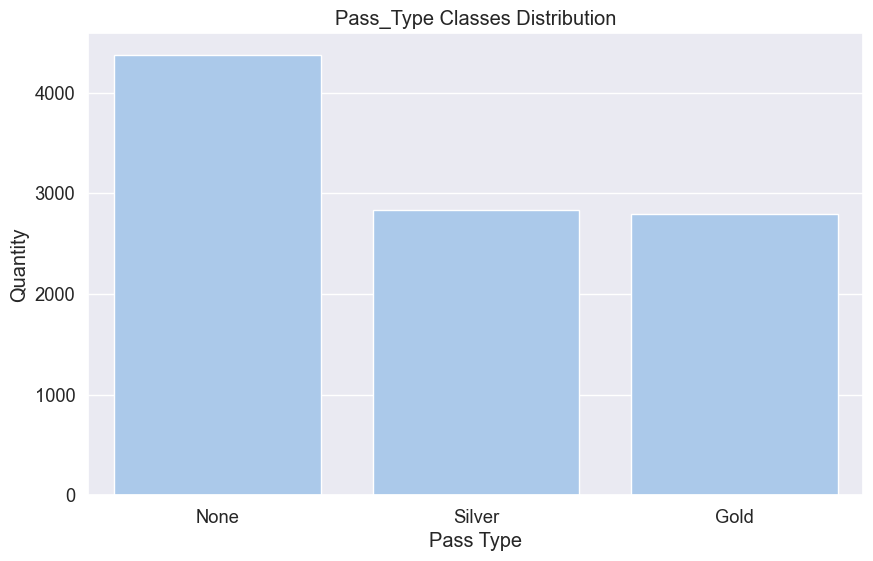

In [4]:
sns.set_theme(style="darkgrid", palette="pastel", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

sns.countplot(x='Pass_Type', data=df, order=df['Pass_Type'].value_counts().index)
plt.title("Pass_Type Classes Distribution")
plt.xlabel("Pass Type")
plt.ylabel("Quantity")
plt.show()


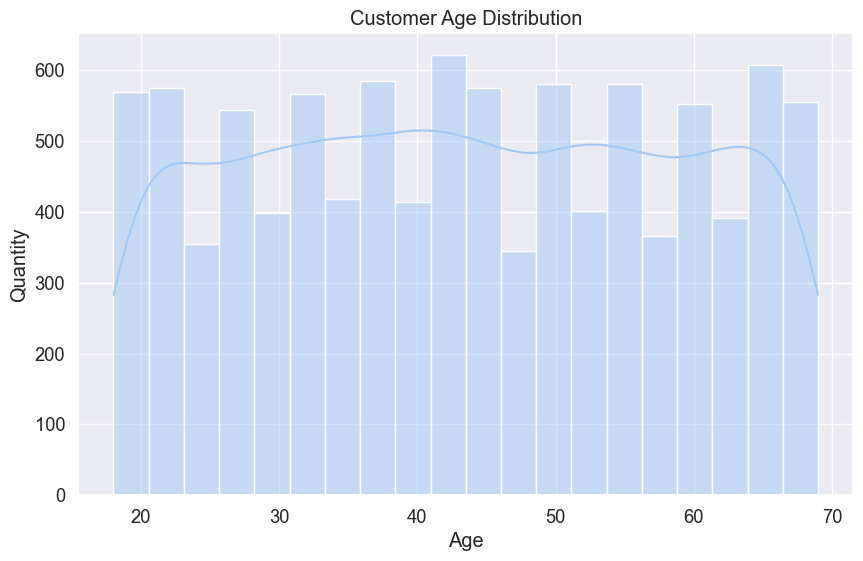

In [5]:
sns.histplot(data=df, x='Age', bins=20, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Quantity")
plt.show()


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

df = pd.read_csv("/Users/adilkhankaldybekov/Desktop/adilkhan/Machine Learning/Projects/Project for Uni 2/data/EU-Park-Customers.csv")
df['Pass_Type'] = df['Pass_Type'].fillna('None')
df = df.drop(columns=['Telephone_Number'])  

df['Has_Pass'] = df['Pass_Type'].apply(lambda x: 1 if x in ['Gold', 'Silver'] else 0)

X = df.drop(columns=['Pass_Type', 'Has_Pass'])  
y = df['Has_Pass']  

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["No Pass", "Has Pass"]))

              precision    recall  f1-score   support

     No Pass       0.89      0.89      0.89       874
    Has Pass       0.92      0.92      0.92      1126

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



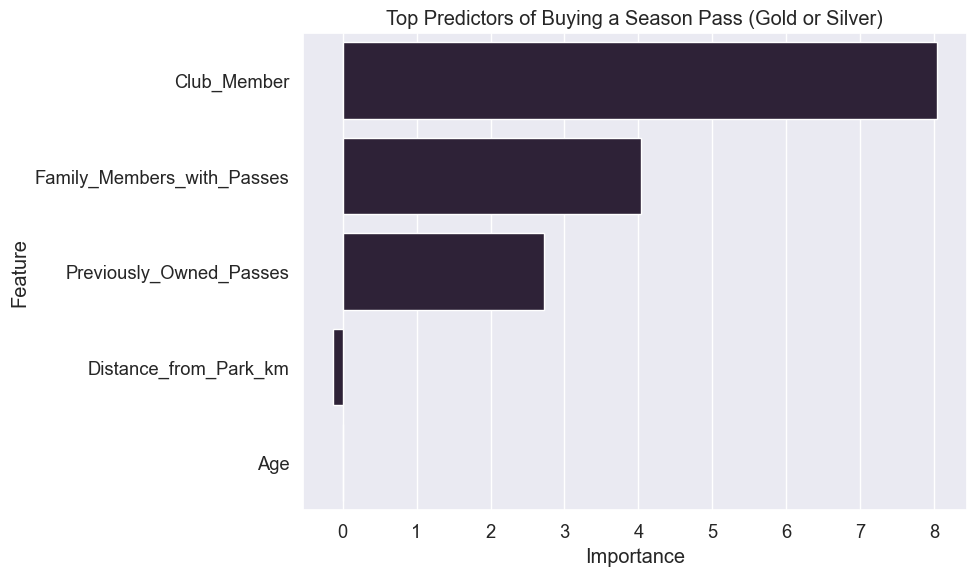

In [7]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', key=np.abs, ascending=False)

sns.set_theme(style="darkgrid", palette="mako", font_scale=1.2)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title("Top Predictors of Buying a Season Pass (Gold or Silver)")
plt.tight_layout()
plt.show()

### 🔍 Interpretation: Top Predictors of Buying a Season Pass (Gold or Silver)

1. **Club_Member** – the strongest positive predictor  
   Customers who are club members are **significantly more likely** to purchase a season pass.  
   🔹 *Insight:* The membership program is highly effective and should be further promoted and expanded.

2. **Family_Members_with_Passes** – strong social influence  
   Having family members with passes **increases the likelihood** of a customer buying one too.  
   🔹 *Insight:* Social influence matters — referrals or family bundle offers could drive sales.

3. **Previously_Owned_Passes** – repeat behavior  
   Customers who have previously purchased passes are **more likely to buy again**.  
   🔹 *Insight:* This reflects customer loyalty. Targeted renewal offers could be very effective.

4. **Distance_from_Park_km** – mild negative impact  
   The farther a customer lives from the park, the **less likely** they are to buy a pass.  
   🔹 *Insight:* Consider local promotions or remote engagement options for distant customers.

5. **Age** – minimal effect  
   The customer's age appears to have **little influence** on the decision to purchase.  
   🔹 *Insight:* Age-specific marketing is likely not necessary.


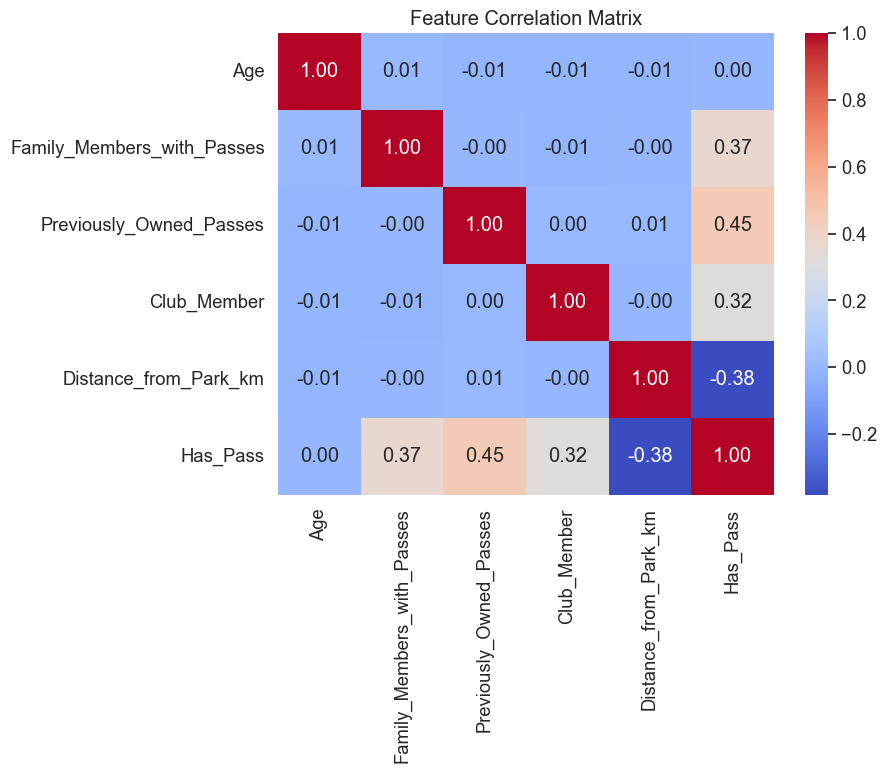

In [8]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

***Upgraded Model - LightGBM***

[LightGBM] [Info] Number of positive: 4502, number of negative: 3498
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.562750 -> initscore=0.252330
[LightGBM] [Info] Start training from score 0.252330
LightGBM Classification Report:

              precision    recall  f1-score   support

     No Pass       0.90      0.90      0.90       874
    Has Pass       0.92      0.92      0.92      1126

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



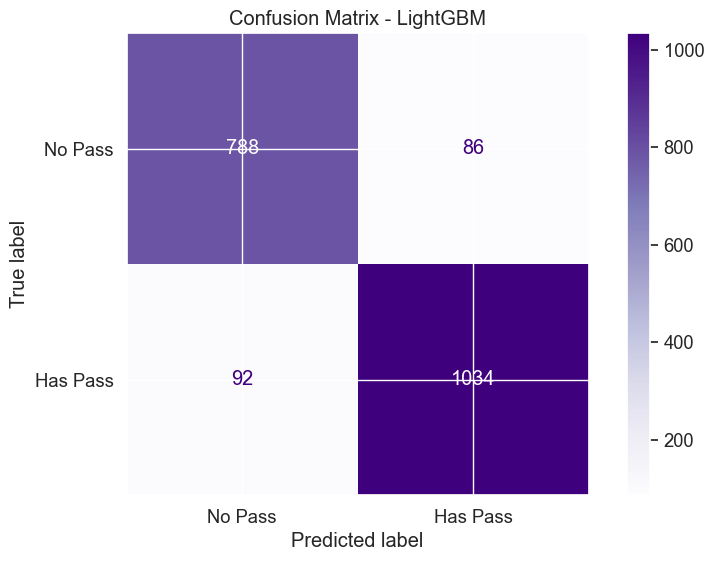

In [9]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM Classification Report:\n")
print(classification_report(y_test, y_pred_lgb, target_names=["No Pass", "Has Pass"]))

cm = confusion_matrix(y_test, y_pred_lgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Pass", "Has Pass"])
disp.plot(cmap='Purples')
plt.title("Confusion Matrix - LightGBM")
plt.show()


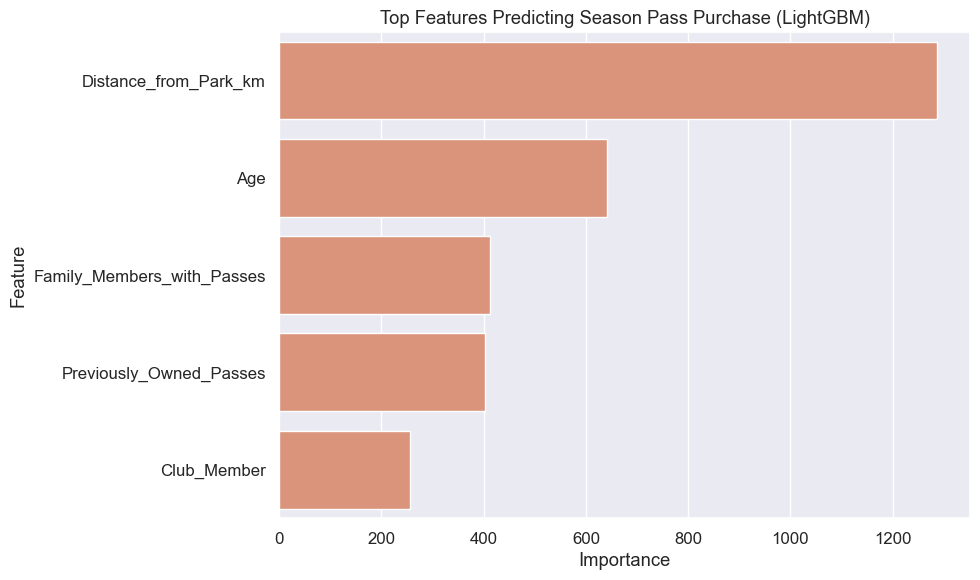

In [10]:
import pandas as pd
import numpy as np

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.set_theme(style="darkgrid", palette="flare", font_scale=1.1)
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title("Top Features Predicting Season Pass Purchase (LightGBM)")
plt.tight_layout()
plt.show()





###  Why the Differences?

- **Logistic Regression** measures *direct linear impact* (positive or negative effect on log-odds).
- **LightGBM** measures *contribution to prediction quality* — i.e., how often and how effectively a feature is used in decision trees.

---

### Summary

- Use **Logistic Regression** to understand simple, explainable effects.
- Use **LightGBM** to uncover deeper, non-linear patterns that may not be obvious.
- Together, they give a **complementary understanding** of customer behavior.
